# IV.2.3 — Temporal Characteristic Analysis of BISINDO Skeleton Data

This notebook generates visualizations to document **temporal issues/characteristics**
found in the BISINDO skeleton data before pre-processing.

Three analysis groups:
1. **IV.2.3.1 — Sequence Length Distribution** → Overall histogram, per-signer boxplot
2. **IV.2.3.2 — Sequence Length Variation Across Sentences** → Per-sentence boxplot, length vs gloss count scatter
3. **IV.2.3.3 — Intra-signer Temporal Inconsistency** → Per-repetition length variance, CV heatmap

---

In [16]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from collections import defaultdict
import os

# ── Paper-style global rcParams ───────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.linewidth'     : 0.8,
    'axes.grid'          : False,
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'figure.titlesize'   : 11,
    'figure.titleweight' : 'bold',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
})

# ── Color palette (consistent with spatial_analysis.ipynb) ────────────────────
C_LH     = '#2166AC'   # Left hand  — deep blue
C_RH     = '#D6604D'   # Right hand — muted red
C_MED    = '#B2182B'   # Median line
C_MEAN   = '#555555'   # Mean reference line
C_EDGE   = '#555555'

# ── Colorblind-safe signer palette (same order as spatial notebook) ───────────
SIGNER_COLORS = ['#2166AC', '#D6604D', '#1A9641', '#7B2D8B', '#E08214', '#555555']

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = '../data/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Configuration loaded.')

Configuration loaded.


## 0. Load Data


In [22]:
PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

# Kecualikan P6, batasi R1–R4
ALLOWED_REPS = {'R1', 'R2', 'R3', 'R4'}
video_ids = [
    v for v in data.keys()
    if v.split('_')[2] in ALLOWED_REPS
]
print(f'Total videos : {len(video_ids)}')
print(f'Sample IDs   : {video_ids[:5]}')

speakers  = sorted(set(v.split('_')[0] for v in video_ids))
sentences = sorted(set(v.split('_')[1] for v in video_ids))
reps      = sorted(set(v.split('_')[2] for v in video_ids))

print(f'Signers    : {speakers}')
print(f'Sentences  : {len(sentences)} total — {sentences[:5]} ...')
print(f'Reps       : {reps}')

seq_len = {vid: data[vid]['keypoints'].shape[0] for vid in video_ids}

print(f'\nSequence length — min: {min(seq_len.values())}  '
      f'max: {max(seq_len.values())}  '
      f'mean: {np.mean(list(seq_len.values())):.1f}')

Total videos : 600
Sample IDs   : ['P1_S01_R1', 'P1_S01_R2', 'P1_S01_R3', 'P1_S01_R4', 'P2_S01_R1']
Signers    : ['P1', 'P2', 'P3', 'P4', 'P5']
Sentences  : 30 total — ['S01', 'S02', 'S03', 'S04', 'S05'] ...
Reps       : ['R1', 'R2', 'R3', 'R4']

Sequence length — min: 81  max: 485  mean: 201.8


---
## IV.2.3.1 — Sequence Length Distribution

Two visualizations:
- **Fig A** — Histogram of sequence length distribution across entire dataset
- **Fig B** — Boxplot of sequence length per signer


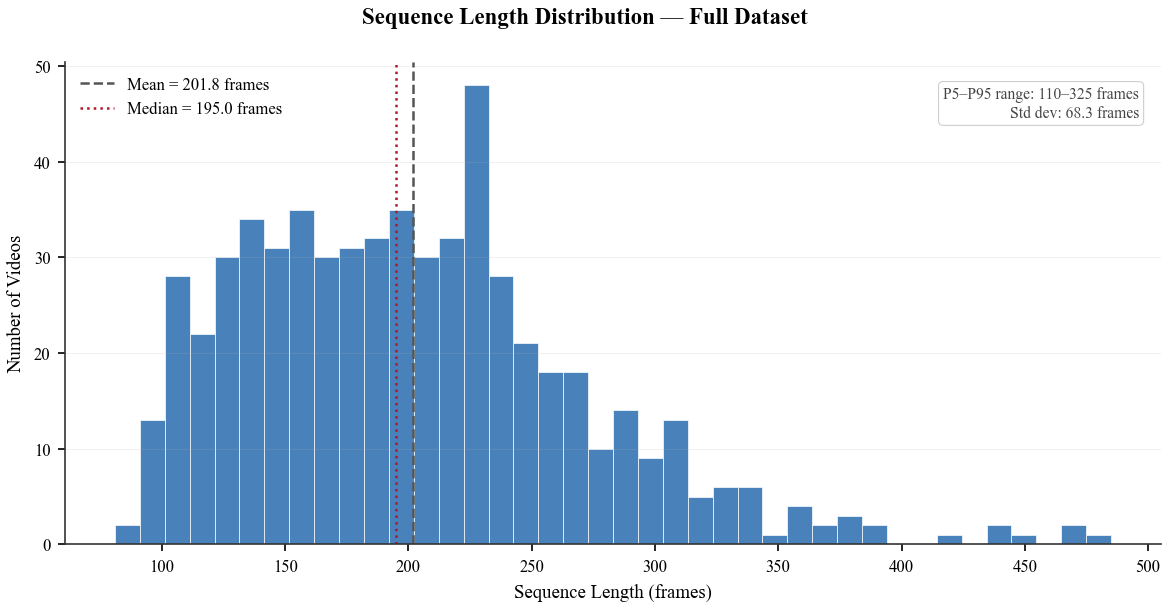

[SAVED] ../data/results\temporal_A_length_histogram.png


In [18]:
# ── Fig A: Sequence Length Distribution — Full Dataset ────────────────────────
# Shows how sequence lengths are distributed overall.
# A wide or skewed distribution justifies the need for temporal normalization.

lengths = np.array(list(seq_len.values()))

fig, ax = plt.subplots(figsize=(8, 4.2), dpi=150)

ax.hist(
    lengths,
    bins=40,
    color='#2166AC',
    alpha=0.82,
    edgecolor='white',
    linewidth=0.4
)

# Mean and median reference lines
mean_len   = lengths.mean()
median_len = np.median(lengths)

ax.axvline(
    mean_len, color='#555555', linestyle='--',
    linewidth=1.2, label=f'Mean = {mean_len:.1f} frames'
)
ax.axvline(
    median_len, color=C_MED, linestyle=':',
    linewidth=1.2, label=f'Median = {median_len:.1f} frames'
)

ax.set_xlabel('Sequence Length (frames)')
ax.set_ylabel('Number of Videos')
ax.grid(axis='y', alpha=0.22, linewidth=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, fontsize=8)

# Annotate percentile range
p5, p95 = np.percentile(lengths, 5), np.percentile(lengths, 95)
ax.text(
    0.98, 0.95,
    f'P5–P95 range: {p5:.0f}–{p95:.0f} frames\n'
    f'Std dev: {lengths.std():.1f} frames',
    transform=ax.transAxes,
    fontsize=7.5, color='#444444',
    va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor='#cccccc', linewidth=0.5)
)

plt.suptitle(
    'Sequence Length Distribution — Full Dataset',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'temporal_A_length_histogram.png')
plt.savefig(save_path, dpi=600)
plt.show()
print(f'[SAVED] {save_path}')

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_19668\3511322675.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


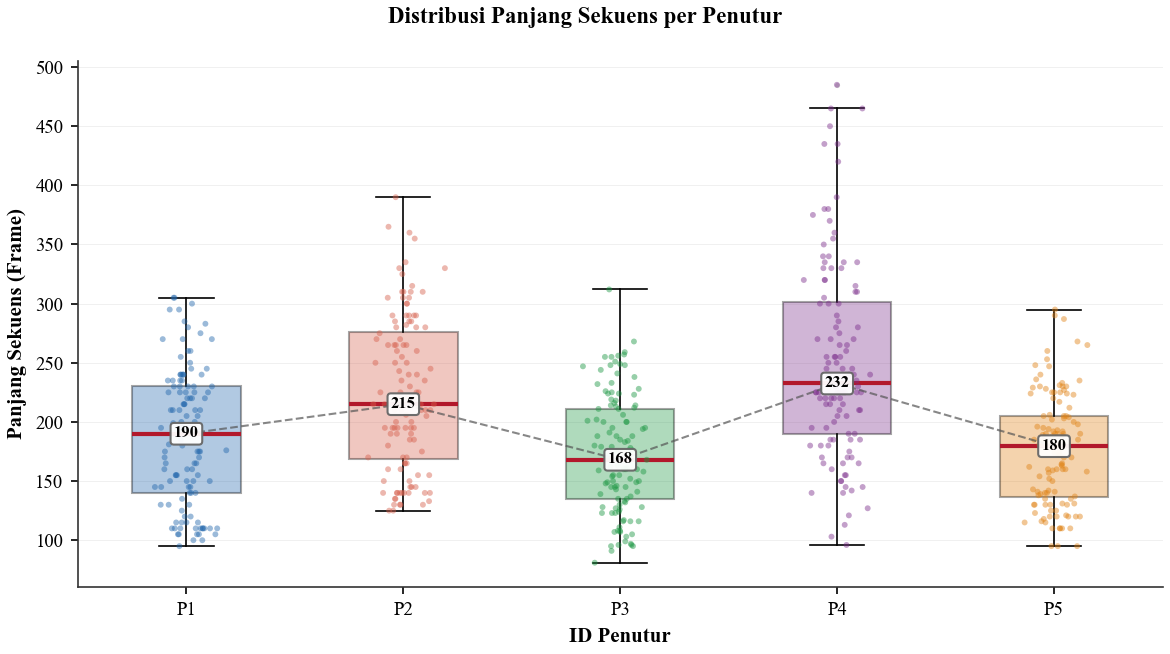

[SAVED] ../data/results\temporal_B_length_per_signer.png

Median Length per Signer
-----------------------------------
    P1: 190.0 frames
    P2: 215.0 frames
    P3: 168.0 frames
    P4: 232.5 frames
    P5: 179.5 frames

DESCRIPTIVE STATISTICS OF SEQUENCE LENGTH PER SIGNER
Signer       N     Min      Q1    Median      Mean      Q3     Max       Std       IQR
--------------------------------------------------------------------------------------
P1         120      95   140.0     190.0     186.6   230.0     305      57.0      90.0
P2         120     125   168.8     215.0     223.2   276.2     390      64.2     107.5
P3         120      81   134.5     168.0     172.2   211.2     312      48.8      76.8
P4         120      96   190.0     232.5     250.2   301.2     485      82.7     111.2
P5         120      95   136.5     179.5     176.6   205.2     295      46.5      68.8

GLOBAL STATISTICS
N      : 600
Min    : 81
Q1     : 150.0
Median : 195.0
Mean   : 201.8
Q3     : 240.0
Max    : 

In [19]:
# ── Fig B: Sequence Length Distribution per Signer ────────────────────────────
# Menampilkan median setiap penutur secara eksplisit

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import os

sp_lengths = defaultdict(list)

for vid, T in seq_len.items():
    sp = vid.split('_')[0]
    sp_lengths[sp].append(T)

sp_sorted = sorted(sp_lengths.keys())
bdata = [sp_lengths[s] for s in sp_sorted]

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)

bp = ax.boxplot(
    bdata,
    labels=sp_sorted,
    patch_artist=True,
    medianprops=dict(
        color=C_MED,
        linewidth=2.0
    ),
    whiskerprops=dict(
        linewidth=0.8
    ),
    capprops=dict(
        linewidth=0.8
    ),
    flierprops=dict(
        marker='o',
        markersize=2.5,
        alpha=0.35,
        markeredgecolor='none',
        markerfacecolor='#888888'
    )
)

# ── Color boxes ──────────────────────────────────────────────────────────────
for patch, color in zip(bp['boxes'], SIGNER_COLORS[:len(sp_sorted)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

# ── Overlay individual samples ───────────────────────────────────────────────
for i, (sp, color) in enumerate(zip(sp_sorted, SIGNER_COLORS)):
    
    ys = sp_lengths[sp]
    xs = np.random.normal(i + 1, 0.06, size=len(ys))
    
    ax.scatter(
        xs,
        ys,
        s=8,
        color=color,
        alpha=0.45,
        edgecolors='none',
        zorder=3
    )

# ── Median values ────────────────────────────────────────────────────────────
medians = [np.median(sp_lengths[s]) for s in sp_sorted]

# Dashed line connecting medians
ax.plot(
    np.arange(1, len(sp_sorted) + 1),
    medians,
    linestyle='--',
    linewidth=1.0,
    color='#555555',
    alpha=0.7,
    zorder=4
)

# Median labels
for i, med in enumerate(medians):

    ax.text(
        i + 1,
        med,
        f'{med:.0f}',
        ha='center',
        va='center',
        fontsize=8,
        fontweight='bold',
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='#666666',
            boxstyle='round,pad=0.2',
            alpha=0.95
        ),
        zorder=5
    )


# ── Formatting ───────────────────────────────────────────────────────────────
ax.set_xlabel(
    'ID Penutur',
    fontsize=10,
    fontweight='bold'
)

ax.set_ylabel(
    'Panjang Sekuens (Frame)',
    fontsize=10,
    fontweight='bold'
)

ax.tick_params(
    axis='both',
    labelsize=9
)

ax.grid(
    axis='y',
    alpha=0.22,
    linewidth=0.4
)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.suptitle(
    'Distribusi Panjang Sekuens per Penutur',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

save_path = os.path.join(
    OUTPUT_DIR,
    'temporal_B_length_per_signer.png'
)

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print(f'[SAVED] {save_path}')

# ── Print median summary ─────────────────────────────────────────────────────
print('\nMedian Length per Signer')
print('-' * 35)

for sp, med in zip(sp_sorted, medians):
    print(f'{sp:>6}: {med:.1f} frames')
    
# ── Descriptive Statistics per Signer ────────────────────────────────────────

print('\n' + '=' * 95)
print('DESCRIPTIVE STATISTICS OF SEQUENCE LENGTH PER SIGNER')
print('=' * 95)

header = (
    f"{'Signer':<8}"
    f"{'N':>6}"
    f"{'Min':>8}"
    f"{'Q1':>8}"
    f"{'Median':>10}"
    f"{'Mean':>10}"
    f"{'Q3':>8}"
    f"{'Max':>8}"
    f"{'Std':>10}"
    f"{'IQR':>10}"
)

print(header)
print('-' * len(header))

for sp in sp_sorted:

    arr = np.array(sp_lengths[sp])

    n      = len(arr)
    min_v  = np.min(arr)
    q1     = np.percentile(arr, 25)
    med    = np.median(arr)
    mean_v = np.mean(arr)
    q3     = np.percentile(arr, 75)
    max_v  = np.max(arr)
    std_v  = np.std(arr)
    iqr_v  = q3 - q1

    print(
        f"{sp:<8}"
        f"{n:>6}"
        f"{min_v:>8.0f}"
        f"{q1:>8.1f}"
        f"{med:>10.1f}"
        f"{mean_v:>10.1f}"
        f"{q3:>8.1f}"
        f"{max_v:>8.0f}"
        f"{std_v:>10.1f}"
        f"{iqr_v:>10.1f}"
    )

# ── Global Statistics ────────────────────────────────────────────────────────

all_lengths = np.array(lengths)

print('\n' + '=' * 95)
print('GLOBAL STATISTICS')
print('=' * 95)

print(f'N      : {len(all_lengths)}')
print(f'Min    : {np.min(all_lengths):.0f}')
print(f'Q1     : {np.percentile(all_lengths, 25):.1f}')
print(f'Median : {np.median(all_lengths):.1f}')
print(f'Mean   : {np.mean(all_lengths):.1f}')
print(f'Q3     : {np.percentile(all_lengths, 75):.1f}')
print(f'Max    : {np.max(all_lengths):.0f}')
print(f'Std    : {np.std(all_lengths):.1f}')
print(f'IQR    : {np.percentile(all_lengths,75)-np.percentile(all_lengths,25):.1f}')

---
## IV.2.3.2 — Sequence Length Variation Across Sentences

Two visualizations:
- **Fig C** — Boxplot of sequence length per sentence (sorted by median)
- **Fig D** — Scatter plot: sequence length vs gloss count per sentence


C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_19668\2981764767.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_19668\2981764767.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8)


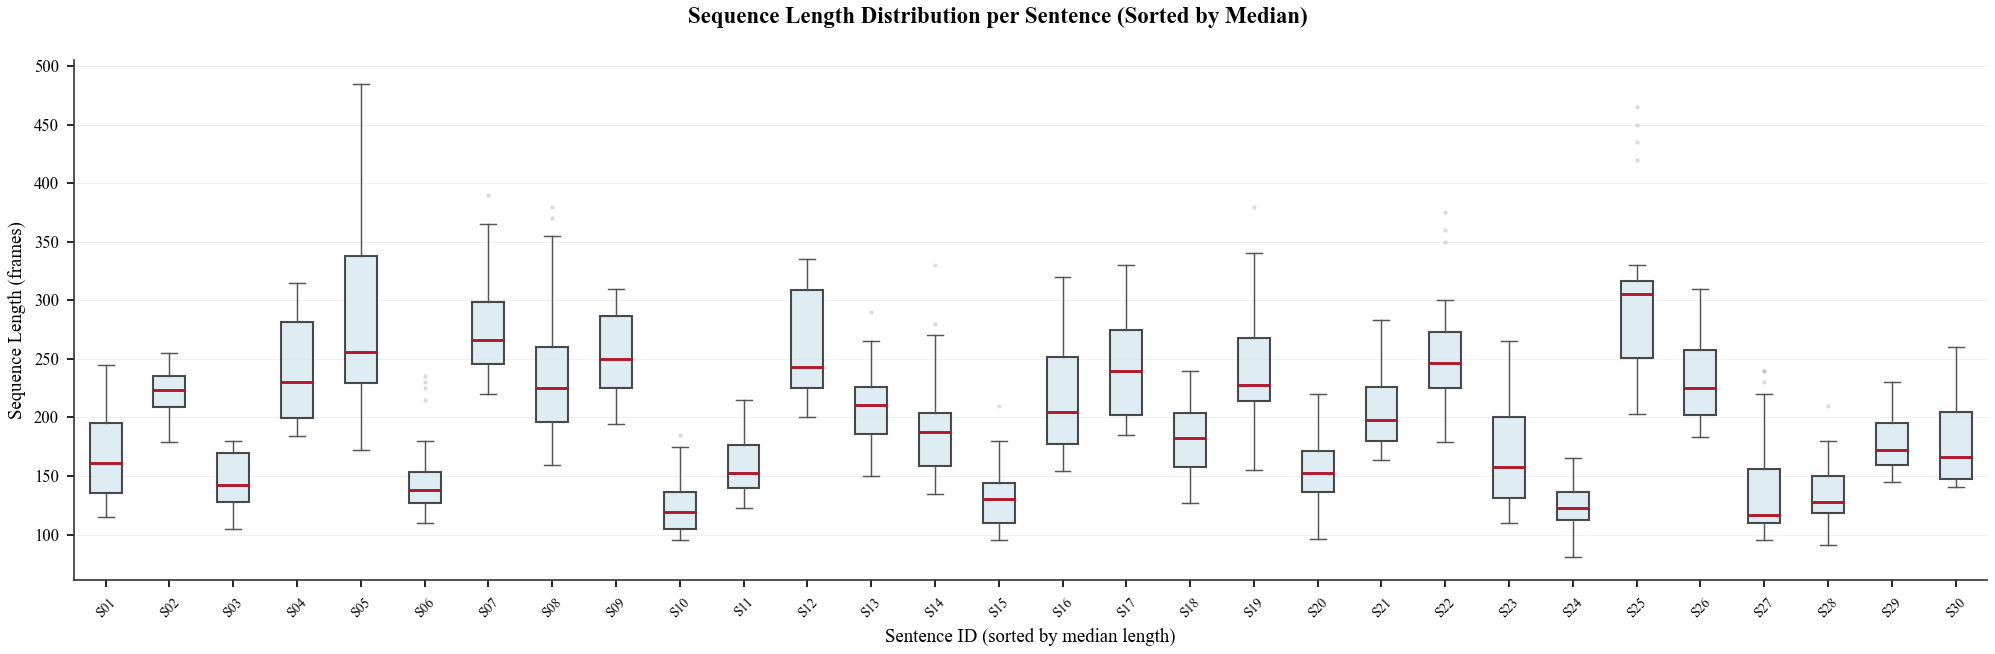

[SAVED] ../data/results\temporal_C_length_per_sentence.png

DESCRIPTIVE STATISTICS OF SEQUENCE LENGTH PER SENTENCE
Sentence       N     Min      Q1    Median      Mean      Q3     Max       Std       IQR
----------------------------------------------------------------------------------------
S01           20     115   135.2     161.0     167.8   195.0     245      39.2      59.8
S02           20     179   208.8     223.5     221.8   235.0     255      18.3      26.2
S03           20     105   127.5     142.5     145.8   170.0     180      22.7      42.5
S04           20     184   199.5     230.0     241.2   281.2     315      44.1      81.8
S05           20     172   229.0     256.0     290.1   337.5     485      90.0     108.5
S06           20     110   127.2     138.0     150.8   153.8     235      40.8      26.5
S07           20     220   245.5     266.5     280.1   298.8     390      46.7      53.2
S08           20     159   196.2     225.0     241.2   260.0     380      63.7      

In [20]:
# ── Fig C: Sequence Length Boxplot per Sentence (sorted by median) ───────────
# Shows that sentence complexity (gloss count) naturally drives length variation.
# Also reveals outlier sentences that are disproportionately long or short.

sent_lengths = defaultdict(list)
for vid, T in seq_len.items():
    sent = vid.split('_')[1]
    sent_lengths[sent].append(T)

# Urutan asli dari dictionary (tanpa sorting)
sent_sorted = list(sent_lengths.keys())
bdata_sent  = [sent_lengths[s] for s in sent_sorted]

# ── Dynamic figure width based on number of sentences ────────────────────────
n_sent  = len(sent_sorted)
fig_w   = max(10, n_sent * 0.45)

fig, ax = plt.subplots(figsize=(fig_w, 4.5), dpi=150)

bp = ax.boxplot(
    bdata_sent,
    labels=sent_sorted,
    patch_artist=True,
    medianprops=dict(color=C_MED, linewidth=1.4),
    whiskerprops=dict(linewidth=0.7, color='#555555'),
    capprops=dict(linewidth=0.7, color='#555555'),
    flierprops=dict(
        marker='o', markersize=2.0,
        alpha=0.3, markeredgecolor='none',
        markerfacecolor='#888888'
    )
)

for patch in bp['boxes']:
    patch.set_facecolor('#D1E5F0')
    patch.set_alpha(0.7)


ax.set_xlabel('Sentence ID (sorted by median length)')
ax.set_ylabel('Sequence Length (frames)')
ax.tick_params(axis='x', labelsize=6.5, rotation=45)
ax.grid(axis='y', alpha=0.22, linewidth=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, fontsize=8)

plt.suptitle(
    'Sequence Length Distribution per Sentence (Sorted by Median)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'temporal_C_length_per_sentence.png')
plt.savefig(save_path, dpi=600)
plt.show()
print(f'[SAVED] {save_path}')

# ── Descriptive Statistics per Sentence ──────────────────────────────────────

print('\n' + '=' * 110)
print('DESCRIPTIVE STATISTICS OF SEQUENCE LENGTH PER SENTENCE')
print('=' * 110)

header = (
    f"{'Sentence':<10}"
    f"{'N':>6}"
    f"{'Min':>8}"
    f"{'Q1':>8}"
    f"{'Median':>10}"
    f"{'Mean':>10}"
    f"{'Q3':>8}"
    f"{'Max':>8}"
    f"{'Std':>10}"
    f"{'IQR':>10}"
)

print(header)
print('-' * len(header))

for sent in sent_sorted:

    arr = np.array(sent_lengths[sent])

    n      = len(arr)
    min_v  = np.min(arr)
    q1     = np.percentile(arr, 25)
    med    = np.median(arr)
    mean_v = np.mean(arr)
    q3     = np.percentile(arr, 75)
    max_v  = np.max(arr)
    std_v  = np.std(arr)
    iqr_v  = q3 - q1

    print(
        f"{sent:<10}"
        f"{n:>6}"
        f"{min_v:>8.0f}"
        f"{q1:>8.1f}"
        f"{med:>10.1f}"
        f"{mean_v:>10.1f}"
        f"{q3:>8.1f}"
        f"{max_v:>8.0f}"
        f"{std_v:>10.1f}"
        f"{iqr_v:>10.1f}"
    )

# ── Summary of shortest & longest sentences ──────────────────────────────────

sentence_medians = {
    s: np.median(sent_lengths[s])
    for s in sent_lengths
}

shortest_sent = min(sentence_medians, key=sentence_medians.get)
longest_sent  = max(sentence_medians, key=sentence_medians.get)

print('\n' + '=' * 110)
print('SUMMARY')
print('=' * 110)

print(
    f"Shortest median sequence : "
    f"{shortest_sent} ({sentence_medians[shortest_sent]:.1f} frames)"
)

print(
    f"Longest median sequence  : "
    f"{longest_sent} ({sentence_medians[longest_sent]:.1f} frames)"
)

print(
    f"Median range             : "
    f"{max(sentence_medians.values()) - min(sentence_medians.values()):.1f} frames"
)

print(
    f"Global median            : "
    f"{np.median(lengths):.1f} frames"
)

print(
    f"Global mean              : "
    f"{np.mean(lengths):.1f} frames"
)

print(
    f"Global std               : "
    f"{np.std(lengths):.1f} frames"
)

[INFO] GLOSS_COUNT not provided — showing mean length per sentence instead.


NameError: name 'global_mean' is not defined

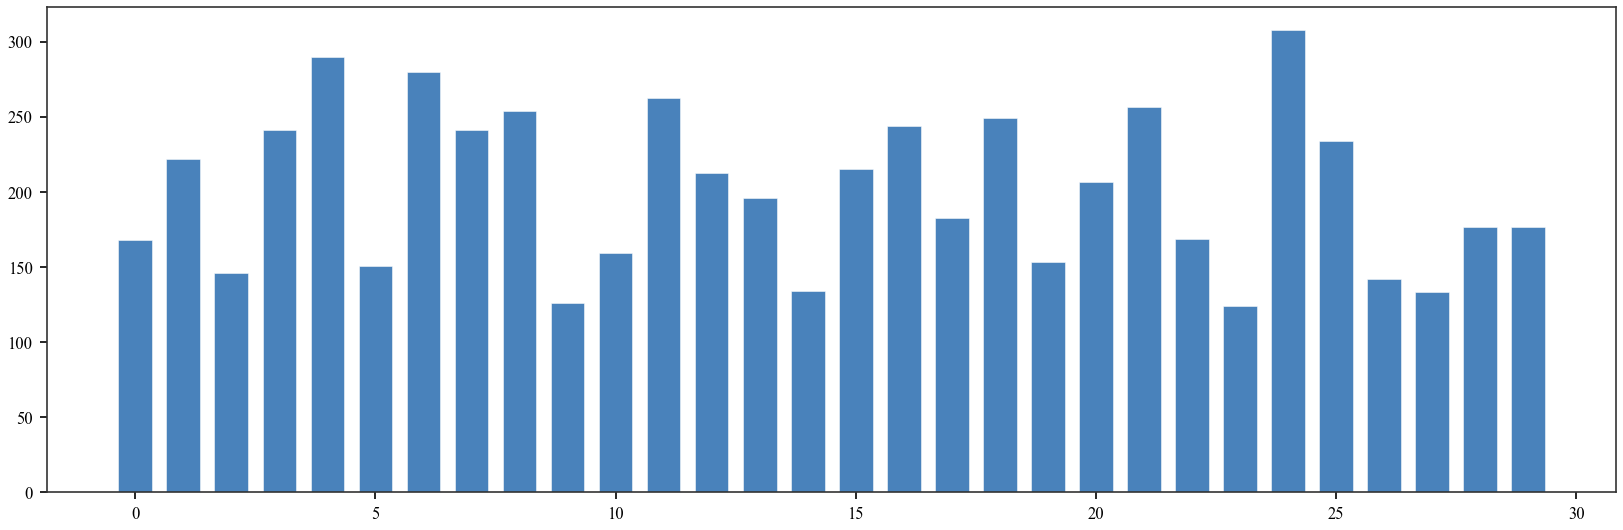

In [21]:
# ── Fig D: Sequence Length vs Gloss Count per Sentence ───────────────────────
# Tests whether longer sentences (more glosses) produce proportionally longer sequences.
# Justifies downsampling ratio selection: if correlation is strong, a fixed ratio is unreliable.

# ── CONFIGURATION — provide gloss count per sentence ─────────────────────────
# Format: {'S001': 3, 'S002': 5, ...}
# If not available, this cell computes mean length per sentence only.
GLOSS_COUNT = {}   # Fill this dict with your gloss count per sentence ID
# ──────────────────────────────────────────────────────────────────────────────

sent_mean_len = {
    s: np.mean(sent_lengths[s]) for s in sent_sorted
}

if GLOSS_COUNT:
    # ── Scatter: mean length vs gloss count ───────────────────────────────────
    common = [s for s in sent_sorted if s in GLOSS_COUNT]
    x_gloss = [GLOSS_COUNT[s] for s in common]
    y_len   = [sent_mean_len[s] for s in common]

    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

    ax.scatter(
        x_gloss, y_len,
        s=30, color='#2166AC',
        alpha=0.7, edgecolors='white', linewidths=0.4
    )

    # Linear fit
    coef = np.polyfit(x_gloss, y_len, 1)
    xfit = np.linspace(min(x_gloss), max(x_gloss), 100)
    ax.plot(
        xfit, np.polyval(coef, xfit),
        color='#D6604D', linewidth=1.2,
        linestyle='--', label=f'Linear fit (slope={coef[0]:.1f} fr/gloss)'
    )

    # Pearson r
    r = np.corrcoef(x_gloss, y_len)[0, 1]
    ax.text(
        0.97, 0.06,
        f'r = {r:.3f}',
        transform=ax.transAxes,
        fontsize=8, ha='right',
        color='#444444'
    )

    ax.set_xlabel('Gloss Count per Sentence')
    ax.set_ylabel('Mean Sequence Length (frames)')

else:
    # ── Fallback: bar chart of mean length per sentence ───────────────────────
    print('[INFO] GLOSS_COUNT not provided — showing mean length per sentence instead.')

    fig, ax = plt.subplots(figsize=(max(10, n_sent * 0.45), 4.2), dpi=150)

    x = np.arange(len(sent_sorted))
    y = [sent_mean_len[s] for s in sent_sorted]

    ax.bar(
        x, y, width=0.7,
        color='#2166AC', alpha=0.82,
        edgecolor='white', linewidth=0.3
    )
    ax.axhline(
        global_mean, color=C_MEAN, linestyle='--',
        linewidth=1.0, alpha=0.7,
        label=f'Global mean = {global_mean:.1f} frames'
    )

    ax.set_xticks(x)
    ax.set_xticklabels(sent_sorted, fontsize=6.5, rotation=45, ha='right')
    ax.set_xlabel('Sentence ID (sorted by median length)')
    ax.set_ylabel('Mean Sequence Length (frames)')

ax.grid(axis='y', alpha=0.22, linewidth=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, fontsize=8)

plt.suptitle(
    'Mean Sequence Length per Sentence'
    + (' vs Gloss Count' if GLOSS_COUNT else ''),
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'temporal_D_length_vs_gloss.png')
plt.savefig(save_path, dpi=600)
plt.show()
print(f'[SAVED] {save_path}')

---
## IV.2.3.3 — Intra-signer Temporal Inconsistency

Two visualizations:
- **Fig E** — Per-repetition length variance: same signer, same sentence, different reps
- **Fig F** — Coefficient of Variation (CV) heatmap: signer × sentence


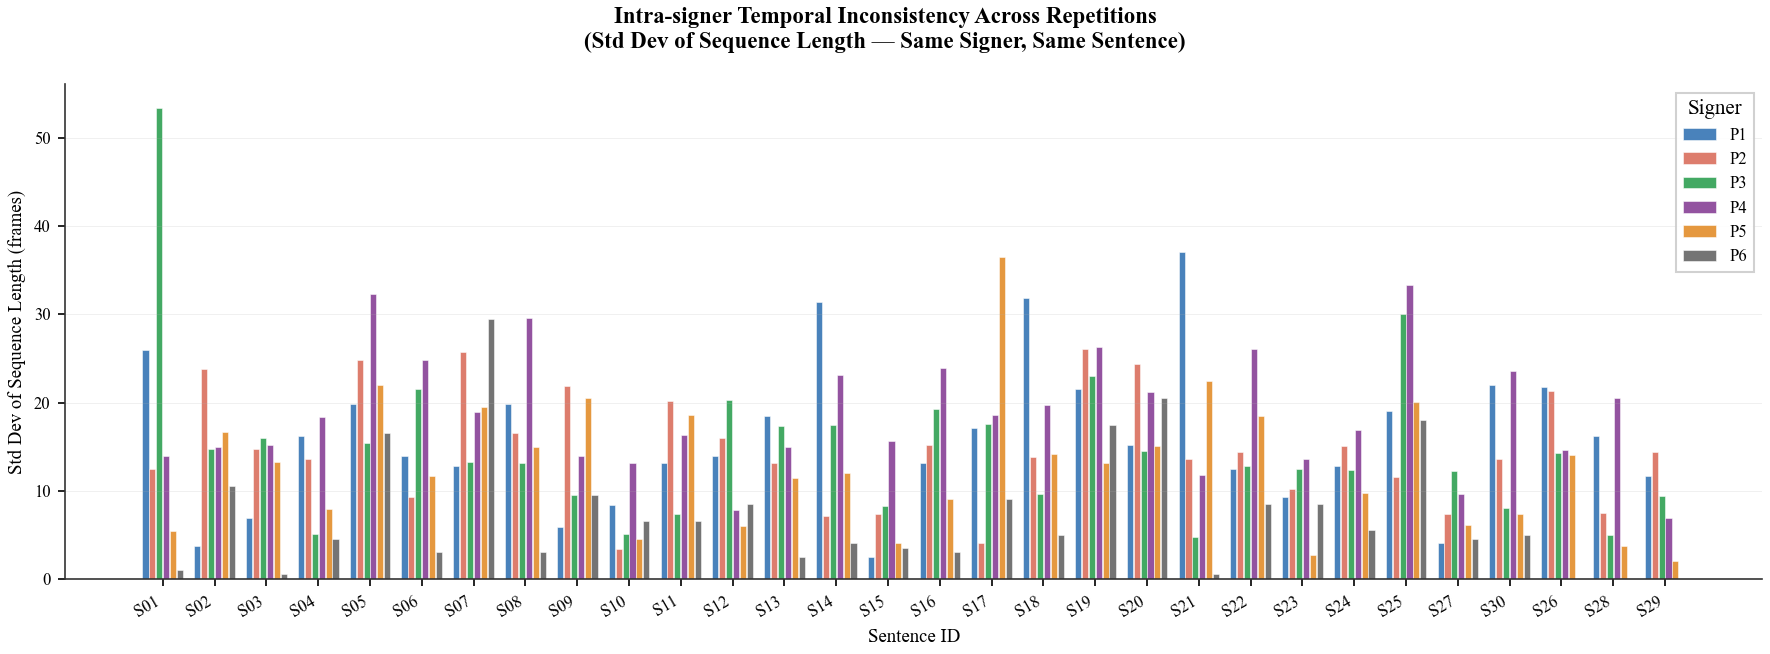

[SAVED] ../data/results\temporal_E_intra_signer_variance.png


In [ ]:
# ── Fig E: Intra-signer Length Variance Across Repetitions ───────────────────
# Same signer, same sentence, different repetitions → how much does length vary?
# Shows that even controlled recordings have temporal inconsistency.

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
N_SENTENCES_SHOW = 30   # Number of sentences to show (those with most reps)
# ──────────────────────────────────────────────────────────────────────────────

# Build: (signer, sentence) -> list of lengths per rep
sp_sent_lens = defaultdict(list)
for vid, T in seq_len.items():
    parts = vid.split('_')
    sp, sent = parts[0], parts[1]
    sp_sent_lens[(sp, sent)].append(T)

# Select sentences where multiple reps exist for most signers
sent_rep_counts = defaultdict(int)
for (sp, sent), lens in sp_sent_lens.items():
    if len(lens) > 1:
        sent_rep_counts[sent] += 1

top_sents = sorted(
    sent_rep_counts, key=sent_rep_counts.get, reverse=True
)[:N_SENTENCES_SHOW]

# ── Plot: grouped bars — one group per sentence, bars per signer ──────────────
n_sent_show = len(top_sents)
n_sp        = len(speakers)
x           = np.arange(n_sent_show)
bar_w       = 0.8 / n_sp

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)

for i, (sp, color) in enumerate(zip(sp_sorted, SIGNER_COLORS)):
    stds = []
    for sent in top_sents:
        lens = sp_sent_lens.get((sp, sent), [])
        stds.append(np.std(lens) if len(lens) > 1 else 0)

    offset = (i - n_sp / 2 + 0.5) * bar_w
    ax.bar(
        x + offset, stds, width=bar_w * 0.88,
        color=color, alpha=0.82,
        edgecolor='white', linewidth=0.3,
        label=sp
    )

ax.set_xticks(x)
ax.set_xticklabels(top_sents, fontsize=8, rotation=30, ha='right')
ax.set_xlabel('Sentence ID')
ax.set_ylabel('Std Dev of Sequence Length (frames)')
ax.grid(axis='y', alpha=0.22, linewidth=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(
    title='Signer', frameon=True,
    framealpha=0.9, edgecolor='#cccccc',
    fancybox=False, fontsize=8,
    loc='upper right'
)

plt.suptitle(
    'Intra-signer Temporal Inconsistency Across Repetitions\n'
    '(Std Dev of Sequence Length — Same Signer, Same Sentence)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'temporal_E_intra_signer_variance.png')
plt.savefig(save_path, dpi=600)
plt.show()
print(f'[SAVED] {save_path}')

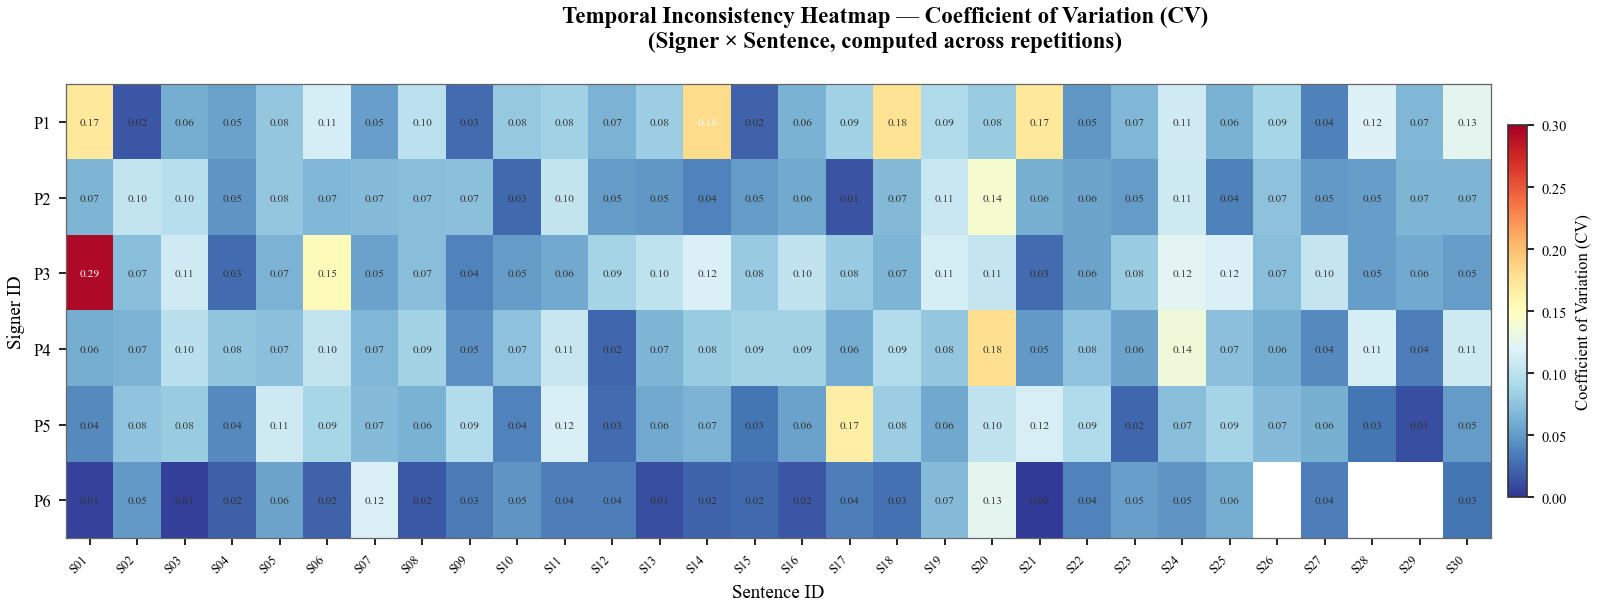

[SAVED] ../data/results\temporal_F_cv_heatmap_sorted.png


In [ ]:
# ── Fig F: Coefficient of Variation Heatmap (Signer × Sentence) ──────────────
# CV = std / mean
# Higher CV indicates higher temporal inconsistency
# Sentences sorted sequentially from S001 → S030

# ── EXTRACT SENTENCE IDS FROM VIDEO IDS ──────────────────────────────────────

sp_sorted = sorted(speakers)

sent_sorted = sorted(
    list(set([
        vid.split('_')[1]   # Take sentence part from P01_S001_R01
        for vid in video_ids
    ])),
    key=lambda x: int(x.replace('S', ''))
)

# ── BUILD CV MATRIX ──────────────────────────────────────────────────────────

cv_matrix = np.full(
    (len(sp_sorted), len(sent_sorted)),
    np.nan
)

for i, sp in enumerate(sp_sorted):

    for j, sent in enumerate(sent_sorted):

        lens = sp_sent_lens.get((sp, sent), [])

        # Need at least 2 repetitions
        if len(lens) > 1 and np.mean(lens) > 0:

            cv_matrix[i, j] = (
                np.std(lens) /
                np.mean(lens)
            )

# ── FIGURE SIZE ──────────────────────────────────────────────────────────────

fig_w = max(
    12,
    len(sent_sorted) * 0.38
)

fig_h = max(
    3.2,
    len(sp_sorted) * 0.7
)

fig, ax = plt.subplots(
    figsize=(fig_w, fig_h),
    dpi=150
)

# ── HEATMAP ──────────────────────────────────────────────────────────────────

im = ax.imshow(
    cv_matrix,
    aspect='auto',
    cmap='RdYlBu_r',
    vmin=0,
    vmax=0.30
)

# ── COLORBAR ─────────────────────────────────────────────────────────────────

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.82,
    pad=0.01
)

cbar.set_label(
    'Coefficient of Variation (CV)',
    fontsize=8
)

cbar.ax.tick_params(
    labelsize=7
)

# ── CELL VALUE ANNOTATION ────────────────────────────────────────────────────

for i in range(len(sp_sorted)):

    for j in range(len(sent_sorted)):

        val = cv_matrix[i, j]

        if not np.isnan(val):

            ax.text(
                j,
                i,
                f'{val:.2f}',
                ha='center',
                va='center',
                fontsize=5.5,
                color='white' if val > 0.18 else '#333333'
            )

# ── AXES ─────────────────────────────────────────────────────────────────────

ax.set_xticks(
    np.arange(len(sent_sorted))
)

ax.set_xticklabels(
    sent_sorted,
    fontsize=6,
    rotation=45,
    ha='right'
)

ax.set_yticks(
    np.arange(len(sp_sorted))
)

ax.set_yticklabels(
    sp_sorted,
    fontsize=8
)

ax.set_xlabel(
    'Sentence ID',
    fontsize=9
)

ax.set_ylabel(
    'Signer ID',
    fontsize=9
)

# ── STYLE ────────────────────────────────────────────────────────────────────

for spine in ax.spines.values():

    spine.set_linewidth(0.6)
    spine.set_color('#666666')

# ── TITLE ────────────────────────────────────────────────────────────────────

plt.suptitle(
    'Temporal Inconsistency Heatmap — Coefficient of Variation (CV)\n'
    '(Signer × Sentence, computed across repetitions)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()

# ── SAVE ─────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'temporal_F_cv_heatmap_sorted.png'
)

plt.savefig(
    save_path,
    dpi=600
)

plt.show()

print(f'[SAVED] {save_path}')

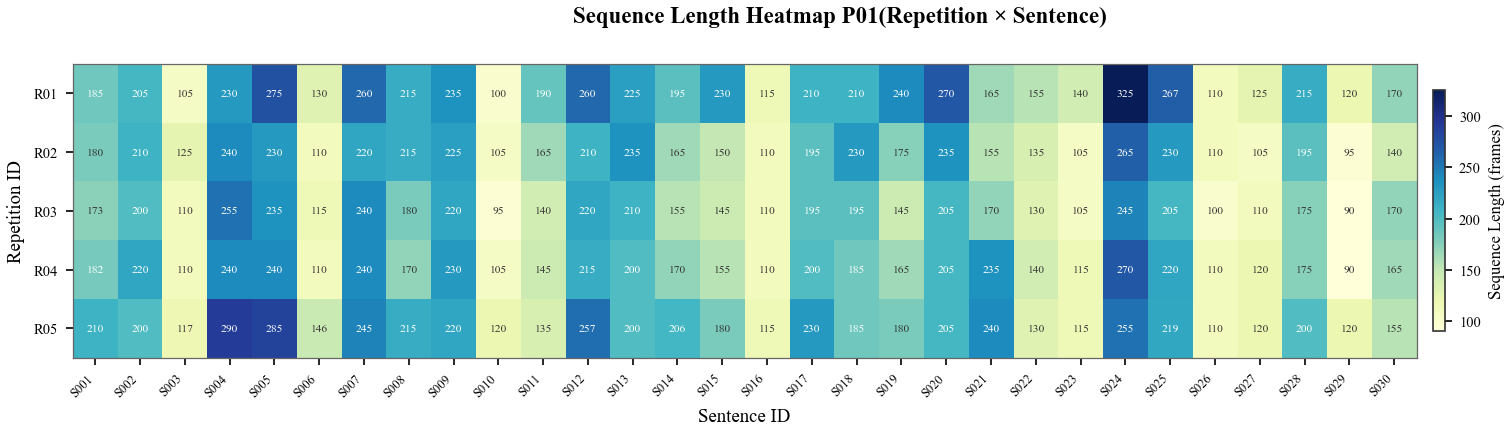

[SAVED] ../data/results\temporal_F2_len_heatmap_P01.png


In [ ]:
# ── Fig F2: Length Heatmap for One Signer (Repetition × Sentence) ─────────────
# Shows raw sequence length per repetition for a single signer

TARGET_SIGNER = 'P1'  # ganti sesuai penutur yang dimaksud

# Sentences sorted S001..S030
sent_sorted = sorted(
    list(set([vid.split('_')[1] for vid in video_ids])),
    key=lambda x: int(x.replace('S', ''))
)

# Repetitions sorted R01..Rxx (only for target signer)
rep_sorted = sorted(
    list(set([
        vid.split('_')[2]
        for vid in video_ids
        if vid.split('_')[0] == TARGET_SIGNER
    ])),
    key=lambda x: int(x.replace('R', ''))
)

# Build length matrix: rows=reps, cols=sentences
len_matrix = np.full((len(rep_sorted), len(sent_sorted)), np.nan)

for i, rep in enumerate(rep_sorted):
    for j, sent in enumerate(sent_sorted):
        vid = f"{TARGET_SIGNER}_{sent}_{rep}"
        if vid in seq_len:
            len_matrix[i, j] = seq_len[vid]

# Figure size
fig_w = max(10, len(sent_sorted) * 0.38)
fig_h = max(3.0, len(rep_sorted) * 0.55)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=150)

im = ax.imshow(
    len_matrix,
    aspect='auto',
    cmap='YlGnBu',
    vmin=np.nanmin(len_matrix),
    vmax=np.nanmax(len_matrix)
)

cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.01)
cbar.set_label('Sequence Length (frames)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# Annotate cell values (optional)
for i in range(len(rep_sorted)):
    for j in range(len(sent_sorted)):
        val = len_matrix[i, j]
        if not np.isnan(val):
            ax.text(
                j, i, f'{val:.0f}',
                ha='center', va='center',
                fontsize=5.5,
                color='white' if val > (np.nanmean(len_matrix)) else '#333333'
            )

ax.set_xticks(np.arange(len(sent_sorted)))
ax.set_xticklabels(sent_sorted, fontsize=6, rotation=45, ha='right')
ax.set_yticks(np.arange(len(rep_sorted)))
ax.set_yticklabels(rep_sorted, fontsize=7)

ax.set_xlabel('Sentence ID', fontsize=9)
ax.set_ylabel('Repetition ID', fontsize=9)

for spine in ax.spines.values():
    spine.set_linewidth(0.6)
    spine.set_color('#666666')

plt.suptitle(
    f'Sequence Length Heatmap {TARGET_SIGNER}(Repetition × Sentence)',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, f'temporal_F2_len_heatmap_{TARGET_SIGNER}.png')
plt.savefig(save_path, dpi=600)
plt.show()

print(f'[SAVED] {save_path}')

---
## Summary — Output Files


In [ ]:
print('='*65)
print('  OUTPUT SUMMARY — IV.2.3 Temporal Characteristic Analysis')
print('='*65)
outputs = [
    ('temporal_A_length_histogram.png',
     'IV.2.3.1 — Sequence length distribution — full dataset'),
    ('temporal_B_length_per_signer.png',
     'IV.2.3.1 — Sequence length boxplot per signer'),
    ('temporal_C_length_per_sentence.png',
     'IV.2.3.2 — Sequence length boxplot per sentence (sorted by median)'),
    ('temporal_D_length_vs_gloss.png',
     'IV.2.3.2 — Mean sequence length per sentence vs gloss count'),
    ('temporal_E_intra_signer_variance.png',
     'IV.2.3.3 — Intra-signer length std dev across repetitions'),
    ('temporal_F_cv_heatmap.png',
     'IV.2.3.3 — CV heatmap: signer x sentence temporal inconsistency'),
]
for fname, desc in outputs:
    path   = os.path.join(OUTPUT_DIR, fname)
    status = '[OK]' if os.path.exists(path) else '[--]'
    print(f'  {status}  {fname}')
    print(f'         → {desc}')
print('='*65)

  OUTPUT SUMMARY — IV.2.3 Temporal Characteristic Analysis
  [OK]  temporal_A_length_histogram.png
         → IV.2.3.1 — Sequence length distribution — full dataset
  [OK]  temporal_B_length_per_signer.png
         → IV.2.3.1 — Sequence length boxplot per signer
  [OK]  temporal_C_length_per_sentence.png
         → IV.2.3.2 — Sequence length boxplot per sentence (sorted by median)
  [OK]  temporal_D_length_vs_gloss.png
         → IV.2.3.2 — Mean sequence length per sentence vs gloss count
  [OK]  temporal_E_intra_signer_variance.png
         → IV.2.3.3 — Intra-signer length std dev across repetitions
  [OK]  temporal_F_cv_heatmap.png
         → IV.2.3.3 — CV heatmap: signer x sentence temporal inconsistency
